# Section 9: Tuning Hyperparameters and Stopping Criteria

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [28]:
# 1. Load Titanic Dataset from OpenML

print('Fetching Titanic dataset from OpenML...')
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
titanic_df = titanic.frame

# 2. Load LendingClub Dataset via OpenML

print('Fetching LendingClub dataset from OpenML...')
lending = fetch_openml(name='lending-club-loan-data', version=1, as_frame=True, parser='auto')
lending_df = lending.frame

print('Datasets loaded successfully!')

Fetching Titanic dataset from OpenML...
Fetching LendingClub dataset from OpenML...
Datasets loaded successfully!


## Titanic Dataset

Titanic is a binary classification problem.

Target:

- `survived = 0`: did not survive
- `survived = 1`: survived

In this section, we tune models using:

1. Manual search  
2. Grid search  
3. Random search  
4. Early stopping  
5. Performance threshold stopping  

In [29]:
# ============================================================
# 9A. Prepare Titanic Dataset
# ============================================================

titanic_model = titanic_df.copy()

target_col = "survived"

# Convert target to integer
titanic_model[target_col] = titanic_model[target_col].astype(int)

# Treat pclass as categorical
if "pclass" in titanic_model.columns:
    titanic_model["pclass"] = titanic_model["pclass"].astype("category")

# Separate X and y first
X_titanic = titanic_model.drop(columns=[target_col]).copy()
y_titanic = titanic_model[target_col].copy()

# Drop columns that are not useful or may cause leakage
cols_to_drop = ["name", "ticket", "cabin", "boat", "body", "home.dest"]
X_titanic = X_titanic.drop(columns=cols_to_drop, errors="ignore")

# Identify categorical and numeric columns
cat_cols = X_titanic.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_titanic.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_titanic[col] = X_titanic[col].astype("object")
    X_titanic[col] = X_titanic[col].fillna("missing")
    X_titanic[col] = X_titanic[col].astype(str).str.strip().str.lower()

# Impute numeric columns
num_imputer = SimpleImputer(strategy="median")
X_titanic[num_cols] = num_imputer.fit_transform(X_titanic[num_cols])

# One-hot encode categorical columns
X_titanic = pd.get_dummies(
    X_titanic,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

print("Titanic X shape:", X_titanic.shape)
print("Titanic y shape:", y_titanic.shape)

display(y_titanic.value_counts(normalize=True))

Titanic X shape: (1309, 10)
Titanic y shape: (1309,)


survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64

In [30]:
# Train-test split

X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.2,
    random_state=42,
    stratify=y_titanic
)

print("Train shape:", X_train_titanic.shape)
print("Test shape:", X_test_titanic.shape)

Train shape: (1047, 10)
Test shape: (262, 10)


### Baseline Model

Before tuning, always train a baseline model.

This gives a benchmark to compare against.

In [31]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train_titanic, y_train_titanic)

baseline_pred = baseline_model.predict(X_test_titanic)
baseline_proba = baseline_model.predict_proba(X_test_titanic)[:, 1]

baseline_results = {
    "model": "Baseline Logistic Regression",
    "accuracy": accuracy_score(y_test_titanic, baseline_pred),
    "precision": precision_score(y_test_titanic, baseline_pred),
    "recall": recall_score(y_test_titanic, baseline_pred),
    "f1": f1_score(y_test_titanic, baseline_pred),
    "roc_auc": roc_auc_score(y_test_titanic, baseline_proba)
}

display(pd.DataFrame([baseline_results]))

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline Logistic Regression,0.805344,0.763441,0.71,0.735751,0.867253


### Manual Search

Manual search means trying a few hyperparameter values based on intuition.

Here we manually tune the regularization strength `C` for Logistic Regression.

- Smaller `C` = stronger regularization
- Larger `C` = weaker regularization

In [32]:
manual_results = []

for C_value in [0.01, 0.1, 1, 10, 100]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C_value,
            max_iter=1000,
            solver="liblinear"
        ))
    ])
    
    model.fit(X_train_titanic, y_train_titanic)
    
    preds = model.predict(X_test_titanic)
    proba = model.predict_proba(X_test_titanic)[:, 1]
    
    manual_results.append({
        "C": C_value,
        "accuracy": accuracy_score(y_test_titanic, preds),
        "precision": precision_score(y_test_titanic, preds),
        "recall": recall_score(y_test_titanic, preds),
        "f1": f1_score(y_test_titanic, preds),
        "roc_auc": roc_auc_score(y_test_titanic, proba)
    })

manual_results_df = pd.DataFrame(manual_results).sort_values("f1", ascending=False)

display(manual_results_df)

,C,accuracy,precision,recall,f1,roc_auc
0,0.01,0.812977,0.774194,0.72,0.746114,0.861698
1,0.10,0.805344,0.757895,0.72,0.738462,0.866327
2,1.00,0.805344,0.763441,0.71,0.735751,0.867315
3,10.00,0.805344,0.763441,0.71,0.735751,0.867562
4,100.00,0.805344,0.763441,0.71,0.735751,0.867623


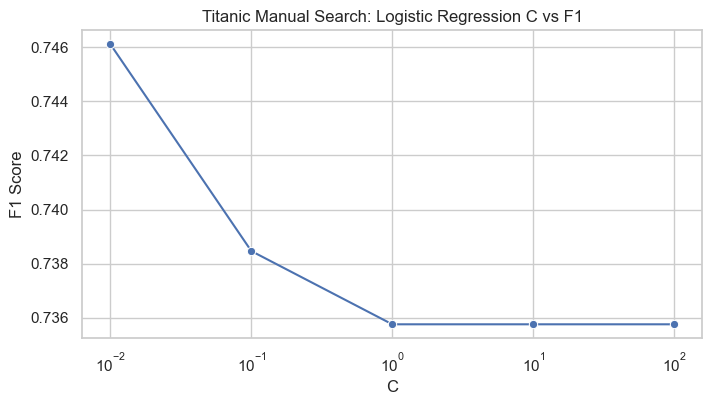

In [33]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=manual_results_df.sort_values("C"), x="C", y="f1", marker="o")
plt.xscale("log")
plt.title("Titanic Manual Search: Logistic Regression C vs F1")
plt.xlabel("C")
plt.ylabel("F1 Score")
plt.show()

### Grid Search

Grid search tries every combination of selected hyperparameter values.

This is useful when the search space is small.

In [34]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, solver="liblinear"))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_titanic, y_train_titanic)

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV F1:")
print(grid_search.best_score_)

Best parameters:
{'model__C': 0.1, 'model__penalty': 'l2'}
Best CV F1:
0.7046949436214549


In [35]:
grid_results_df = pd.DataFrame(grid_search.cv_results_)

display(
    grid_results_df[
        ["param_model__C", "param_model__penalty", "mean_test_score", "std_test_score", "rank_test_score"]
    ].sort_values("rank_test_score")
)

,param_model__C,param_model__penalty,mean_test_score,std_test_score,rank_test_score
3,0.10,l2,0.704695,0.032919,1
4,1.00,l1,0.699710,0.026933,2
2,0.10,l1,0.699215,0.039067,3
5,1.00,l2,0.696933,0.031890,4
6,10.00,l1,0.696933,0.031890,4
7,10.00,l2,0.696933,0.031890,4
9,100.00,l2,0.696933,0.031890,4
8,100.00,l1,0.696933,0.031890,4
1,0.01,l2,0.696773,0.035850,9
0,0.01,l1,0.693197,0.035453,10


In [36]:
best_grid_model = grid_search.best_estimator_

grid_preds = best_grid_model.predict(X_test_titanic)
grid_proba = best_grid_model.predict_proba(X_test_titanic)[:, 1]

print("Grid Search Test Results:")
print(classification_report(y_test_titanic, grid_preds))
print("ROC-AUC:", roc_auc_score(y_test_titanic, grid_proba))

Grid Search Test Results:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       162
           1       0.76      0.72      0.74       100

    accuracy                           0.81       262
   macro avg       0.80      0.79      0.79       262
weighted avg       0.80      0.81      0.80       262

ROC-AUC: 0.8663271604938271


### Random Search

Random search samples random combinations.

This is useful when there are many hyperparameters.

In [37]:
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

param_distributions = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [2, 3, 4, 5, 8, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_titanic, y_train_titanic)

print("Best parameters:")
print(random_search.best_params_)

print("Best CV F1:")
print(random_search.best_score_)

Best parameters:
{'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3}
Best CV F1:
0.7366186826913783


In [38]:
best_random_model = random_search.best_estimator_

random_preds = best_random_model.predict(X_test_titanic)
random_proba = best_random_model.predict_proba(X_test_titanic)[:, 1]

print("Random Search Test Results:")
print(classification_report(y_test_titanic, random_preds))
print("ROC-AUC:", roc_auc_score(y_test_titanic, random_proba))

Random Search Test Results:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       162
           1       0.81      0.74      0.77       100

    accuracy                           0.84       262
   macro avg       0.83      0.82      0.82       262
weighted avg       0.83      0.84      0.83       262

ROC-AUC: 0.8796296296296295


### Early Stopping

Early stopping stops training when validation performance stops improving.

Here we use `HistGradientBoostingClassifier`, which supports early stopping.

In [39]:
early_stop_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=10,
    random_state=42
)

early_stop_model.fit(X_train_titanic, y_train_titanic)

early_preds = early_stop_model.predict(X_test_titanic)
early_proba = early_stop_model.predict_proba(X_test_titanic)[:, 1]

print("Number of boosting iterations used:")
print(early_stop_model.n_iter_)

print("\nEarly Stopping Test Results:")
print(classification_report(y_test_titanic, early_preds))
print("ROC-AUC:", roc_auc_score(y_test_titanic, early_proba))

Number of boosting iterations used:
63

Early Stopping Test Results:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       162
           1       0.79      0.71      0.75       100

    accuracy                           0.82       262
   macro avg       0.81      0.80      0.80       262
weighted avg       0.82      0.82      0.81       262

ROC-AUC: 0.8737654320987654


### Performance Threshold Stopping

Sometimes we stop tuning once a target performance is reached.

Example: stop once F1 score is at least 0.75.

In [40]:
target_f1 = 0.75

threshold_search_results = []

for depth in [2, 3, 4, 5, 6, 8, 10, None]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train_titanic, y_train_titanic)
    preds = model.predict(X_test_titanic)
    
    f1 = f1_score(y_test_titanic, preds)
    
    threshold_search_results.append({
        "max_depth": depth,
        "f1": f1
    })
    
    print(f"max_depth={depth}, F1={f1:.3f}")
    
    if f1 >= target_f1:
        print(f"Stopping early because target F1 of {target_f1} was reached.")
        break

threshold_search_df = pd.DataFrame(threshold_search_results)

display(threshold_search_df)

max_depth=2, F1=0.707
max_depth=3, F1=0.775
Stopping early because target F1 of 0.75 was reached.


,max_depth,f1
0,2,0.707317
1,3,0.774869


# LendingClub Dataset

LendingClub is a binary classification problem.

Target:

- `not.fully.paid = 0`: fully paid
- `not.fully.paid = 1`: not fully paid

Because this dataset is usually imbalanced, we tune models using metrics such as F1, recall, and ROC-AUC.

In [41]:
# ============================================================
# 9B. Prepare LendingClub Dataset
# ============================================================

lc_model = lending_df.copy()

target_col = "not.fully.paid"

# Convert target to integer
lc_model[target_col] = lc_model[target_col].astype(int)

# Separate X and y first
X_lc = lc_model.drop(columns=[target_col]).copy()
y_lc = lc_model[target_col].copy()

# Identify categorical and numeric columns
cat_cols = X_lc.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_lc.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_lc[col] = X_lc[col].astype("object")
    X_lc[col] = X_lc[col].fillna("missing")
    X_lc[col] = X_lc[col].astype(str).str.strip().str.lower()

# Impute numeric columns
num_imputer = SimpleImputer(strategy="median")
X_lc[num_cols] = num_imputer.fit_transform(X_lc[num_cols])

# One-hot encode categorical columns
X_lc = pd.get_dummies(
    X_lc,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Handle infinite or missing values
X_lc = X_lc.replace([np.inf, -np.inf], np.nan)
X_lc = X_lc.fillna(X_lc.median(numeric_only=True))

print("LendingClub X shape:", X_lc.shape)
print("LendingClub y shape:", y_lc.shape)

display(y_lc.value_counts())
display(y_lc.value_counts(normalize=True))

LendingClub X shape: (9578, 18)
LendingClub y shape: (9578,)


not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64

In [42]:
# Train-test split

X_train_lc, X_test_lc, y_train_lc, y_test_lc = train_test_split(
    X_lc,
    y_lc,
    test_size=0.2,
    random_state=42,
    stratify=y_lc
)

print("Train shape:", X_train_lc.shape)
print("Test shape:", X_test_lc.shape)

Train shape: (7662, 18)
Test shape: (1916, 18)


### Baseline Model

For LendingClub, use class weights because the positive class is usually smaller.

In [43]:
lc_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

lc_baseline.fit(X_train_lc, y_train_lc)

lc_baseline_preds = lc_baseline.predict(X_test_lc)
lc_baseline_proba = lc_baseline.predict_proba(X_test_lc)[:, 1]

lc_baseline_results = {
    "model": "Baseline Weighted Logistic Regression",
    "accuracy": accuracy_score(y_test_lc, lc_baseline_preds),
    "precision": precision_score(y_test_lc, lc_baseline_preds, zero_division=0),
    "recall": recall_score(y_test_lc, lc_baseline_preds, zero_division=0),
    "f1": f1_score(y_test_lc, lc_baseline_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_test_lc, lc_baseline_proba)
}

display(pd.DataFrame([lc_baseline_results]))

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline Weighted Logistic Regression,0.640397,0.239071,0.570033,0.336862,0.684468


### Grid Search for Logistic Regression

For LendingClub, we tune Logistic Regression using F1 score.

In [44]:
lc_logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        class_weight="balanced"
    ))
])

lc_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"]
}

lc_grid_search = GridSearchCV(
    estimator=lc_logistic_pipeline,
    param_grid=lc_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

lc_grid_search.fit(X_train_lc, y_train_lc)

print("Best parameters:")
print(lc_grid_search.best_params_)

print("Best CV F1:")
print(lc_grid_search.best_score_)

Best parameters:
{'model__C': 10, 'model__penalty': 'l2'}
Best CV F1:
0.3453636499442137


In [45]:
lc_best_grid_model = lc_grid_search.best_estimator_

lc_grid_preds = lc_best_grid_model.predict(X_test_lc)
lc_grid_proba = lc_best_grid_model.predict_proba(X_test_lc)[:, 1]

print("LendingClub Grid Search Test Results:")
print(classification_report(y_test_lc, lc_grid_preds))
print("ROC-AUC:", roc_auc_score(y_test_lc, lc_grid_proba))

LendingClub Grid Search Test Results:
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      1609
           1       0.24      0.57      0.34       307

    accuracy                           0.64      1916
   macro avg       0.56      0.61      0.55      1916
weighted avg       0.78      0.64      0.69      1916

ROC-AUC: 0.6844763676631649


### Random Search for Random Forest

Random search is useful because Random Forest has many hyperparameters.

In [46]:
lc_rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

lc_param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2"]
}

lc_random_search = RandomizedSearchCV(
    estimator=lc_rf,
    param_distributions=lc_param_distributions,
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

lc_random_search.fit(X_train_lc, y_train_lc)

print("Best parameters:")
print(lc_random_search.best_params_)

print("Best CV F1:")
print(lc_random_search.best_score_)

Best parameters:
{'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 3}
Best CV F1:
0.33913011883235517


In [47]:
lc_best_random_model = lc_random_search.best_estimator_

lc_random_preds = lc_best_random_model.predict(X_test_lc)
lc_random_proba = lc_best_random_model.predict_proba(X_test_lc)[:, 1]

print("LendingClub Random Search Test Results:")
print(classification_report(y_test_lc, lc_random_preds))
print("ROC-AUC:", roc_auc_score(y_test_lc, lc_random_proba))

LendingClub Random Search Test Results:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78      1609
           1       0.25      0.52      0.34       307

    accuracy                           0.68      1916
   macro avg       0.57      0.61      0.56      1916
weighted avg       0.78      0.68      0.71      1916

ROC-AUC: 0.6544042772434373


### Early Stopping with Gradient Boosting

Early stopping prevents unnecessary training once validation performance stops improving.

In [48]:
lc_early_stop_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=10,
    class_weight="balanced",
    random_state=42
)

lc_early_stop_model.fit(X_train_lc, y_train_lc)

lc_early_preds = lc_early_stop_model.predict(X_test_lc)
lc_early_proba = lc_early_stop_model.predict_proba(X_test_lc)[:, 1]

print("Number of boosting iterations used:")
print(lc_early_stop_model.n_iter_)

print("\nLendingClub Early Stopping Test Results:")
print(classification_report(y_test_lc, lc_early_preds))
print("ROC-AUC:", roc_auc_score(y_test_lc, lc_early_proba))

Number of boosting iterations used:
34

LendingClub Early Stopping Test Results:
              precision    recall  f1-score   support

           0       0.88      0.67      0.76      1609
           1       0.24      0.53      0.33       307

    accuracy                           0.65      1916
   macro avg       0.56      0.60      0.55      1916
weighted avg       0.78      0.65      0.69      1916

ROC-AUC: 0.6501428244625609


### Performance Threshold Stopping

In a lending problem, we might care about recall for risky loans.

Example: stop tuning once recall for `not_fully_paid = 1` reaches 0.70.

In [49]:
target_recall = 0.70

threshold_results_lc = []

for C_value in [0.001, 0.01, 0.1, 1, 10, 100]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C_value,
            max_iter=1000,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])
    
    model.fit(X_train_lc, y_train_lc)
    preds = model.predict(X_test_lc)
    
    recall = recall_score(y_test_lc, preds, zero_division=0)
    precision = precision_score(y_test_lc, preds, zero_division=0)
    f1 = f1_score(y_test_lc, preds, zero_division=0)
    
    threshold_results_lc.append({
        "C": C_value,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })
    
    print(f"C={C_value}, Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")
    
    if recall >= target_recall:
        print(f"Stopping early because target recall of {target_recall} was reached.")
        break

threshold_results_lc_df = pd.DataFrame(threshold_results_lc)

display(threshold_results_lc_df)

C=0.001, Precision=0.237, Recall=0.596, F1=0.339
C=0.01, Precision=0.239, Recall=0.583, F1=0.339
C=0.1, Precision=0.240, Recall=0.573, F1=0.338
C=1, Precision=0.239, Recall=0.570, F1=0.337
C=10, Precision=0.239, Recall=0.570, F1=0.337
C=100, Precision=0.239, Recall=0.570, F1=0.337


,C,precision,recall,f1
0,0.001,0.236740,0.596091,0.338889
1,0.010,0.239305,0.583062,0.339336
2,0.100,0.239782,0.573290,0.338136
3,1.000,0.239398,0.570033,0.337187
4,10.000,0.239398,0.570033,0.337187
5,100.000,0.239398,0.570033,0.337187


## Compare Tuning Methods

Different tuning methods have different tradeoffs.

- Manual search is simple but limited.
- Grid search is exhaustive but expensive.
- Random search is efficient for larger spaces.
- Early stopping saves training time.
- Performance threshold stopping is useful for business-driven goals.

In [50]:
tuning_methods = pd.DataFrame({
    "method": [
        "Manual Search",
        "Grid Search",
        "Random Search",
        "Bayesian Optimization",
        "Gradient-Based Optimization",
        "Early Stopping",
        "Performance Threshold Stopping"
    ],
    "best_for": [
        "Small problems and intuition-based exploration",
        "Small search spaces",
        "Large or high-dimensional search spaces",
        "Expensive models where each run is costly",
        "Neural networks and differentiable objectives",
        "Boosting and neural networks",
        "Business-driven model development"
    ],
    "advantage": [
        "Simple and easy to understand",
        "Tries every combination",
        "Efficient and often better than grid search",
        "Learns which hyperparameters to try next",
        "Can directly optimize model parameters",
        "Avoids unnecessary training",
        "Stops once target performance is good enough"
    ],
    "limitation": [
        "May miss good combinations",
        "Can be very slow",
        "Results depend on random samples",
        "Requires extra libraries such as Optuna or scikit-optimize",
        "Not applicable to all models",
        "Needs validation set or validation fraction",
        "May stop before finding the best model"
    ]
})

display(tuning_methods)

,method,best_for,advantage,limitation
0,Manual Search,Small problems and intuition-based exploration,Simple and easy to understand,May miss good combinations
1,Grid Search,Small search spaces,Tries every combination,Can be very slow
2,Random Search,Large or high-dimensional search spaces,Efficient and often better than grid search,Results depend on random samples
3,Bayesian Optimization,Expensive models where each run is costly,Learns which hyperparameters to try next,Requires extra libraries such as Optuna or sci...
4,Gradient-Based Optimization,Neural networks and differentiable objectives,Can directly optimize model parameters,Not applicable to all models
5,Early Stopping,Boosting and neural networks,Avoids unnecessary training,Needs validation set or validation fraction
6,Performance Threshold Stopping,Business-driven model development,Stops once target performance is good enough,May stop before finding the best model


## Optional: Bayesian Optimization with Optuna

This section is optional.

Install Optuna if needed:

```python
!pip install optuna

In [51]:

# Optional Bayesian optimization example for Titanic
# Run this only if optuna is installed.

try:
    import optuna
    from sklearn.model_selection import cross_val_score

    def objective(trial):
        C = trial.suggest_float("C", 0.001, 100, log=True)
        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                C=C,
                penalty=penalty,
                solver="liblinear",
                max_iter=1000
            ))
        ])

        scores = cross_val_score(
            model, X_train_titanic, y_train_titanic,
            cv=5, scoring="f1"
        )
        return scores.mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=20)

    print("Best CV F1:")
    print(study.best_value)

    print("Best parameters:")
    print(study.best_params)

except ImportError:
    print("Optuna is not installed.")
    print("Install using: pip install optuna")

[I 2026-05-12 10:58:13,106] A new study created in memory with name: no-name-ee15d820-cc4a-448a-9cdf-2d128ce1f671
[I 2026-05-12 10:58:13,271] Trial 0 finished with value: 0.7013097910327113 and parameters: {'C': 0.6930163354837527, 'penalty': 'l1'}. Best is trial 0 with value: 0.7013097910327113.
[I 2026-05-12 10:58:13,396] Trial 1 finished with value: 0.6969326343729461 and parameters: {'C': 88.37477152459012, 'penalty': 'l1'}. Best is trial 0 with value: 0.7013097910327113.
[I 2026-05-12 10:58:13,523] Trial 2 finished with value: 0.6969326343729461 and parameters: {'C': 4.438224740200051, 'penalty': 'l2'}. Best is trial 0 with value: 0.7013097910327113.
[I 2026-05-12 10:58:13,597] Trial 3 finished with value: 0.7036320844374782 and parameters: {'C': 0.2795146500307479, 'penalty': 'l1'}. Best is trial 3 with value: 0.7036320844374782.
[I 2026-05-12 10:58:13,654] Trial 4 finished with value: 0.7029680593945706 and parameters: {'C': 0.3051268534920665, 'penalty': 'l1'}. Best is trial 3 

Best CV F1:
0.7046949436214549
Best parameters:
{'C': 0.09969252716304505, 'penalty': 'l2'}


# Section 9 Summary

Key ideas:

- Hyperparameters are model settings chosen before training.
- Manual search is useful for quick experimentation.
- Grid search is best for small search spaces.
- Random search is better for larger search spaces.
- Bayesian optimization is useful when each model run is expensive.
- Early stopping prevents overtraining.
- Performance threshold stopping is useful when the goal is business-driven.

For Titanic:

- Logistic Regression and Random Forest are good tuning examples.
- F1 and ROC-AUC are useful tuning metrics.

For LendingClub:

- Tune using F1, recall, or ROC-AUC instead of accuracy.
- Weighted models are useful because `not.fully.paid = 1` is usually the minority class.
- Recall may be more important when missing risky loans is expensive.